Imports

In [109]:
#pip install bertopic
#pip install kneed

In [1]:
import re
import json
import matplotlib.pyplot as plt
from bertopic import BERTopic
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_distances
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist, squareform
from sentence_transformers import SentenceTransformer
from kneed import KneeLocator
from transformers import pipeline


Helper functions

In [2]:
def estimate_threshold(Z):
    distances = Z[:, 2]
    kneedle = KneeLocator(range(len(distances)), distances, S=1.0, curve="concave", direction="increasing")
    return distances[kneedle.knee]


def estimate_optimal_clusters(Z):
    distances = Z[:, 2]
    distances_rev = distances[::-1]
    idx = range(1, len(distances_rev) + 1)
    
    # Plot showing the elbow
    plt.plot(range(1, len(distances) + 1), distances[::-1])
    plt.title("Linkage Distances")
    plt.xlabel("Merge Step (Reversed)")
    plt.ylabel("Distance")
    plt.show()
    
    # Use KneeLocator to find the elbow
    knee = KneeLocator(idx, distances_rev, S=1.0, curve="convex", direction="increasing")
    print("Knee point:", knee.knee)
    if knee.knee is None:
        return 2  # fallback value
    else:
        return len(distances) - knee.knee + 1
    

Extract Questions

In [3]:
cq_path = "competency_questions_output/competency_questions_200_documents.txt"

with open(cq_path, "r", encoding="utf-8") as f:
    content = f.read()

# Extract all questions from the file
questions = re.findall(r'\*\*Frage:\*\*\s*(.+?)(?=\n\*\*Quelle:\*\*|\n\d+\.|\Z)', content, re.DOTALL)
# Remove duplicate questions
questions = list(dict.fromkeys(questions))

Clustering and Plotting Function

In [4]:
# This was/is an experiment to implement BERTopic for clustering but i failed, good luck to the next one.
def cluster_and_plot_cq2(distances, model, questions, doc_vectors, method='ward', distance_threshold=1):
    """
    Plot a dendrogram based on the given distance matrix and optionally extract topics using BERTopic.
    
    Parameters:
    - model: Name of the vectorization model (e.g., "TF-IDF" or "SentenceTransformer").
    - method: Linkage method for hierarchical clustering (default: 'ward').
    - questions: List of questions.
    - embeddings: Embeddings for questions.
    """
    
    print(f"\nExtracting topics using BERTopic for {model}...")
    topic_model = BERTopic()
    topics, probs = topic_model.fit_transform(questions, doc_vectors)

    # Combine topics with questions for dendrogram labels
    labeled_questions = [
        f"Topic {topic}: {question}" for topic, question in zip(topics, questions)
    ]
    
    # Perform hierarchical clustering
    Z = linkage(distances, method=method)

    cluster_labels = fcluster(Z, t=distance_threshold, criterion='distance')

    # Print clusters
    print("\nClusters:")
    for cluster_id in set(cluster_labels):
        print(f"Cluster {cluster_id}:")
        for i, label in enumerate(cluster_labels):
            if label == cluster_id:
                print(f"  - {questions[i]}")

    # Create a dendrogram with labeled questions
    plt.figure(figsize=(12, 8))
    dendrogram(
        Z,
        labels=labeled_questions,
        leaf_rotation=90,
        color_threshold=distance_threshold,  # Hide splits below this distance
    )
    plt.title(f"Dendrogram of Competency Questions with {model} Vectorization")
    plt.xlabel("Questions (with Topics)")
    plt.ylabel("Distance")
    plt.legend()
    plt.show()


In [5]:
def cluster_and_plot_cq(distances, model, method='ward', n_clusters=False, max_d=False):
    """
    Plot a dendrogram based on the given distance matrix.
    """
    Z = linkage(distances, method=method)

    if n_clusters:
        cluster_labels = fcluster(Z, t=n_clusters, criterion='maxclust')
    elif max_d:
        cluster_labels = fcluster(Z, t=max_d, criterion='distance')
    else: # Default estimate optimal number of clusters
        n_clusters = estimate_optimal_clusters(Z)
        print(f"Estimated number of clusters: {n_clusters}")
        cluster_labels = fcluster(Z, t=n_clusters, criterion='maxclust')

    clustered_questions = {}
    for cluster_id, question in zip(cluster_labels, questions):
        clustered_questions.setdefault(cluster_id, []).append(question)

    plt.figure(figsize=(10, 7))
    dendrogram(Z, labels=questions, leaf_rotation=90)
    plt.title(f"Dendrogram of Competency Questions with {model} Vectorisation")
    plt.xlabel("Questions")
    plt.ylabel("Distance")
    plt.show()

    return clustered_questions


TF-IDF-Vektorisierung

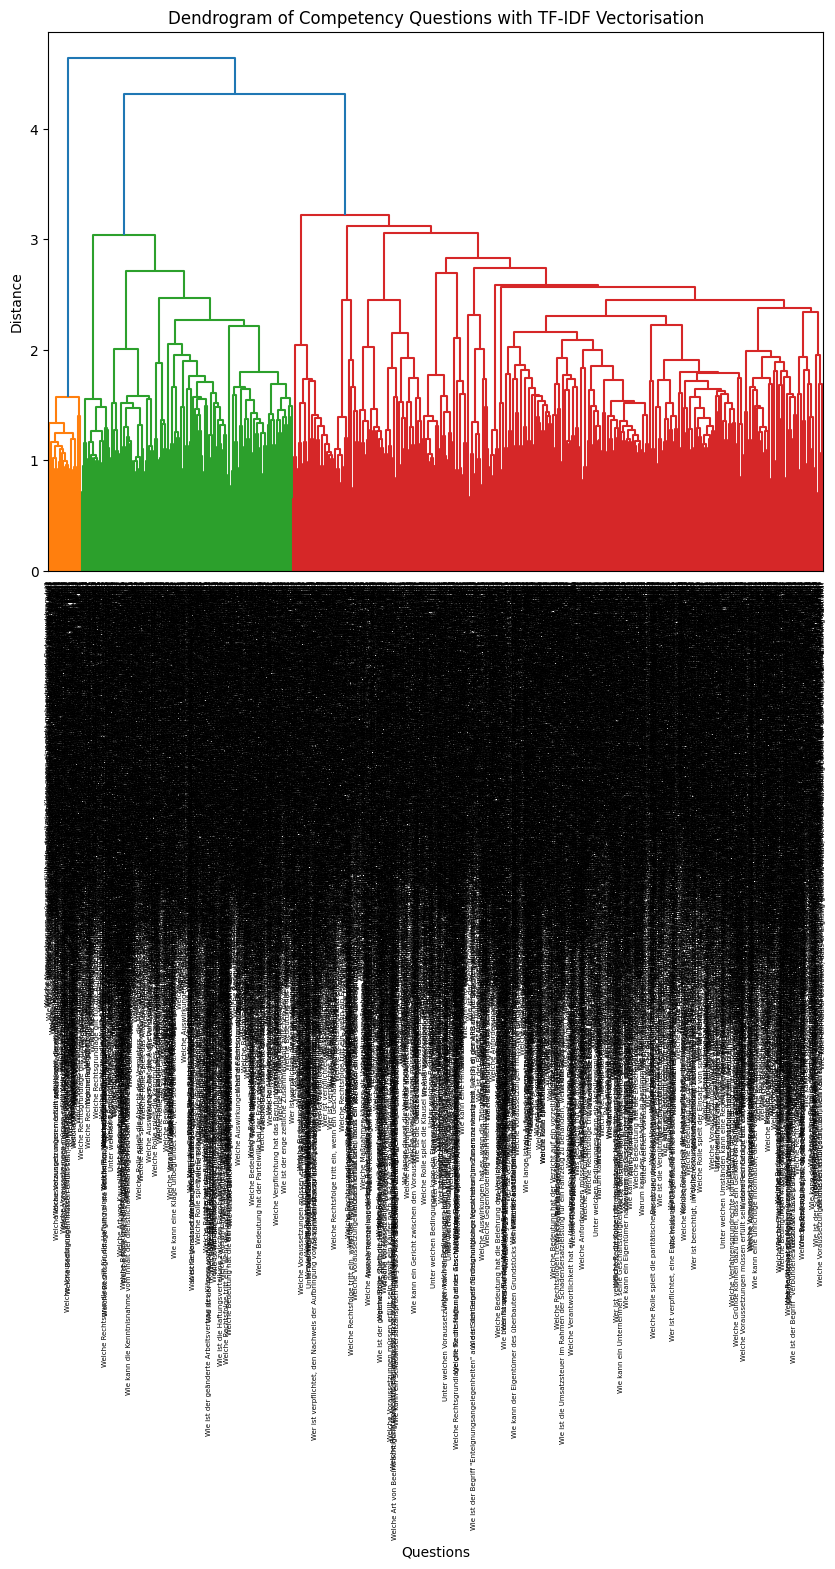

✅ clustered_cq_TF saved as JSON.


In [9]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(questions)

distances = pdist(X.toarray(), metric="cosine")

clustered_cq_TF = cluster_and_plot_cq(distances, "TF-IDF", n_clusters=125)

clustered_cq_TF = {int(k): v for k, v in clustered_cq_TF.items()}

with open("competency_questions_output/clustered_cq_TF.json", "w", encoding="utf-8") as f:
    json.dump(clustered_cq_TF, f, ensure_ascii=False, indent=4)

print("✅ clustered_cq_TF saved as JSON.")

Sentence Embedding Vertorisierung

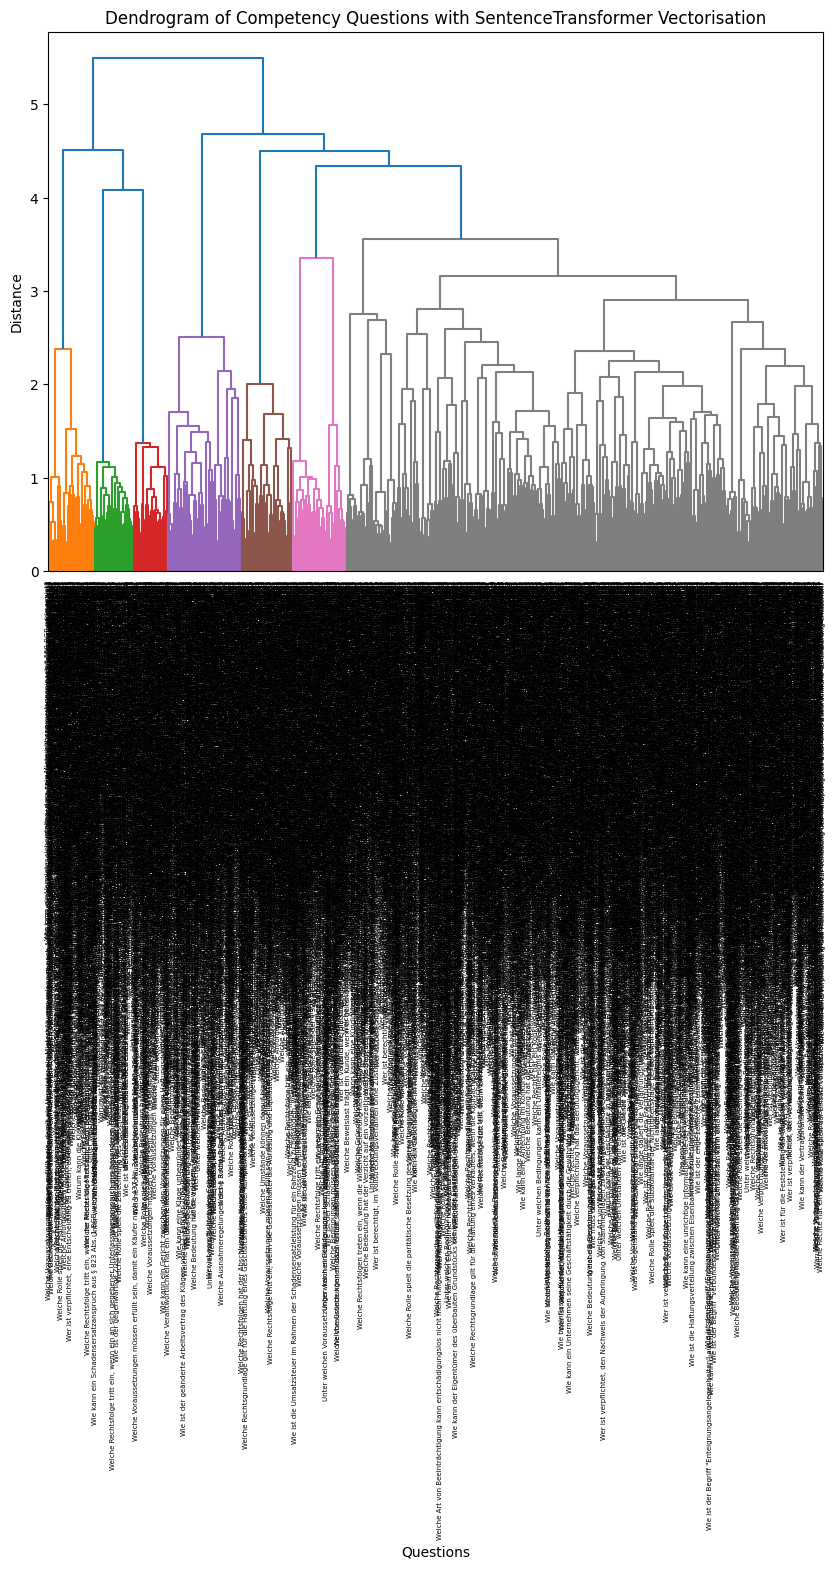

✅ clustered_cq_TF saved as JSON.


In [10]:
model = SentenceTransformer('all-MiniLM-L6-v2')  # You can choose other models from sentence-transformers

# Generate embeddings for all questions
embeddings = model.encode(questions)

# Calculate pairwise cosine distances
distances = pdist(embeddings, metric="cosine")

clustered_cq_SE = cluster_and_plot_cq(distances, "SentenceTransformer", n_clusters=125)

clustered_cq_SE = {int(k): v for k, v in clustered_cq_TF.items()}

with open("competency_questions_output/clustered_cq_SE.json", "w", encoding="utf-8") as f:
    json.dump(clustered_cq_SE, f, ensure_ascii=False, indent=4)

print("✅ clustered_cq_TF saved as JSON.")


Vergleich der Cluster

In [ ]:
## Cluster-Vergleich mit festgelegten Clustern (n_clusters=5)
# Vergleich der Clusterqualität: TF-IDF vs. Sentence Embeddings
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering

# TF-IDF Silhouette Score
vectorizer = TfidfVectorizer()
X_tfidf = vectorizer.fit_transform(questions)
dist_tfidf = pdist(X_tfidf.toarray(), metric="cosine")
X_tfidf_dense = squareform(dist_tfidf)

clustering_tfidf = AgglomerativeClustering(metric='precomputed', linkage='average', n_clusters=5)
labels_tfidf = clustering_tfidf.fit_predict(X_tfidf_dense)
score_tfidf = silhouette_score(X_tfidf_dense, labels_tfidf, metric="precomputed")

# Sentence Embeddings Silhouette Score
from scipy.spatial.distance import pdist, squareform
X_emb_dense = squareform(pdist(embeddings, metric="cosine"))

clustering_emb = AgglomerativeClustering(metric='precomputed', linkage='average', n_clusters=5)
labels_emb = clustering_emb.fit_predict(X_emb_dense)
score_emb = silhouette_score(X_emb_dense, labels_emb, metric="precomputed")

# Ergebnisse ausgeben
print(f"📊 Silhouette Score (TF-IDF): {score_tfidf:.4f}")
print(f"📊 Silhouette Score (Sentence Embeddings): {score_emb:.4f}")

📊 Silhouette Score (TF-IDF): 0.0211
📊 Silhouette Score (Sentence Embeddings): 0.0629


In [ ]:
## Cluster-Vergleich mit variablen/besten Clustern
# Vergleich der Clusterqualität: TF-IDF vs. Sentence Embeddings

from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering

def find_best_n_clusters(distance_matrix, label, max_k=10):
    best_score = -1
    best_k = 2
    best_labels = None

    for k in range(2, max_k + 1):
        clustering = AgglomerativeClustering(n_clusters=k, metric='precomputed', linkage='average')
        labels = clustering.fit_predict(distance_matrix)
        score = silhouette_score(distance_matrix, labels, metric="precomputed")

        print(f"{label} | n_clusters={k} → Silhouette Score: {score:.4f}")

        if score > best_score:
            best_score = score
            best_k = k
            best_labels = labels

    return best_k, best_score, best_labels

# TF-IDF
vectorizer = TfidfVectorizer()
X_tfidf = vectorizer.fit_transform(questions)
dist_tfidf = squareform(pdist(X_tfidf.toarray(), metric="cosine"))

best_k_tfidf, score_tfidf, labels_tfidf = find_best_n_clusters(dist_tfidf, "TF-IDF")

# Sentence Embeddings
dist_emb = squareform(pdist(embeddings, metric="cosine"))
best_k_emb, score_emb, labels_emb = find_best_n_clusters(dist_emb, "Embeddings")

print(f"\n✅ Best TF-IDF clustering: k={best_k_tfidf} | Silhouette Score: {score_tfidf:.4f}")
print(f"✅ Best Embedding clustering: k={best_k_emb} | Silhouette Score: {score_emb:.4f}")

TF-IDF | n_clusters=2 → Silhouette Score: 0.0221
TF-IDF | n_clusters=3 → Silhouette Score: 0.0188
TF-IDF | n_clusters=4 → Silhouette Score: 0.0216
TF-IDF | n_clusters=5 → Silhouette Score: 0.0211
TF-IDF | n_clusters=6 → Silhouette Score: 0.0274
TF-IDF | n_clusters=7 → Silhouette Score: 0.0261
TF-IDF | n_clusters=8 → Silhouette Score: 0.0302
TF-IDF | n_clusters=9 → Silhouette Score: 0.0339
TF-IDF | n_clusters=10 → Silhouette Score: 0.0339
Embeddings | n_clusters=2 → Silhouette Score: 0.1020
Embeddings | n_clusters=3 → Silhouette Score: 0.0771
Embeddings | n_clusters=4 → Silhouette Score: 0.0738
Embeddings | n_clusters=5 → Silhouette Score: 0.0629
Embeddings | n_clusters=6 → Silhouette Score: 0.0644
Embeddings | n_clusters=7 → Silhouette Score: 0.0672
Embeddings | n_clusters=8 → Silhouette Score: 0.0624
Embeddings | n_clusters=9 → Silhouette Score: 0.0901
Embeddings | n_clusters=10 → Silhouette Score: 0.1114

✅ Best TF-IDF clustering: k=10 | Silhouette Score: 0.0339
✅ Best Embedding clus

In [ ]:
## Cluster-Vergleich mit variablen/besten Clustern und zusätzlichen Metriken
# Vergleich der Clusterqualität: TF-IDF vs. Sentence Embeddings

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.cluster import AgglomerativeClustering

# Vergleich der Clusterqualität
X_tfidf = vectorizer.fit_transform(questions)
dist_tfidf = pdist(X_tfidf.toarray(), metric="cosine")
X_tfidf_dense = squareform(dist_tfidf)

X_emb_dense = squareform(pdist(embeddings, metric="cosine"))

# Beste Clusteranzahl pro Cluster-Metrik finden und ausgeben/vergleichen
def find_best_n_clusters(distance_matrix, label, data_matrix, max_k=10):
    best_score = -1
    best_k = 2
    best_labels = None

    for k in range(2, max_k + 1):
        clustering = AgglomerativeClustering(n_clusters=k, metric='precomputed', linkage='average')
        labels = clustering.fit_predict(distance_matrix)
        score = silhouette_score(distance_matrix, labels, metric="precomputed")
        dbs = davies_bouldin_score(data_matrix, labels)
        chs = calinski_harabasz_score(data_matrix, labels)

        print(f"{label} | k={k} → Silhouette: {score:.4f} | DB: {dbs:.4f} | CH: {chs:.2f}")

        if score > best_score:
            best_score = score
            best_k = k
            best_labels = labels

    return best_k, best_score, best_labels

best_k_tfidf, score_tfidf, labels_tfidf = find_best_n_clusters(X_tfidf_dense, "TF-IDF", X_tfidf.toarray())
best_k_emb, score_emb, labels_emb = find_best_n_clusters(X_emb_dense, "Embeddings", embeddings)

print(f"\n✅ Best TF-IDF clustering: k={best_k_tfidf} | Silhouette: {score_tfidf:.4f}")
print(f"✅ Best Embedding clustering: k={best_k_emb} | Silhouette: {score_emb:.4f}")


TF-IDF | k=2 → Silhouette: 0.0221 | DB: 0.9716 | CH: 1.05
TF-IDF | k=3 → Silhouette: 0.0188 | DB: 4.8852 | CH: 2.21
TF-IDF | k=4 → Silhouette: 0.0216 | DB: 4.5415 | CH: 2.42
TF-IDF | k=5 → Silhouette: 0.0211 | DB: 4.1405 | CH: 2.38
TF-IDF | k=6 → Silhouette: 0.0274 | DB: 4.1662 | CH: 2.51
TF-IDF | k=7 → Silhouette: 0.0261 | DB: 3.8984 | CH: 2.33
TF-IDF | k=8 → Silhouette: 0.0302 | DB: 3.7981 | CH: 2.35
TF-IDF | k=9 → Silhouette: 0.0339 | DB: 3.6661 | CH: 2.39
TF-IDF | k=10 → Silhouette: 0.0339 | DB: 3.4727 | CH: 2.28
Embeddings | k=2 → Silhouette: 0.1020 | DB: 2.2137 | CH: 3.10
Embeddings | k=3 → Silhouette: 0.0771 | DB: 1.9260 | CH: 2.62
Embeddings | k=4 → Silhouette: 0.0738 | DB: 2.5437 | CH: 3.30
Embeddings | k=5 → Silhouette: 0.0629 | DB: 3.0086 | CH: 3.27
Embeddings | k=6 → Silhouette: 0.0644 | DB: 2.7587 | CH: 3.29
Embeddings | k=7 → Silhouette: 0.0672 | DB: 2.7296 | CH: 3.68
Embeddings | k=8 → Silhouette: 0.0624 | DB: 2.5765 | CH: 3.47
Embeddings | k=9 → Silhouette: 0.0901 | DB:

In [ ]:
"""
## Clustering Metrics – Interpretation Help
Silhouette Score (−1 to 1):
Higher = better. Measures how well points fit in their cluster.
0.5 = strong, ~0.1 = weak, < 0 = bad.
Davies-Bouldin Score (0+):
Lower = better. Measures cluster overlap.
~1–2 is good, >3 is poor.
Calinski-Harabasz Score (0+):
Higher = better. Measures separation vs. compactness.
Best for comparing runs.
"""

"""
## Clustering Metric Interpretation of our Results
Silhouette Score (higher is better):
Embeddings: 0.0920 vs. TF-IDF: 0.0428 → Embeddings group questions more meaningfully.
Davies-Bouldin Score (lower is better):
Embeddings: ~2.1, TF-IDF: ~4.0 → TF-IDF clusters overlap more.
Calinski-Harabasz Score (higher is better):
Embeddings: 4.25, TF-IDF: 3.94 → Slightly clearer separation with embeddings.
"""

'\n## Clustering Metric Interpretation of our Results\nSilhouette Score (higher is better):\nEmbeddings: 0.0920 vs. TF-IDF: 0.0428 → Embeddings group questions more meaningfully.\nDavies-Bouldin Score (lower is better):\nEmbeddings: ~2.1, TF-IDF: ~4.0 → TF-IDF clusters overlap more.\nCalinski-Harabasz Score (higher is better):\nEmbeddings: 4.25, TF-IDF: 3.94 → Slightly clearer separation with embeddings.\n'

Visualisierung zum Cluster-Qualitäts-Vergleich: TF-IDF vs. Sentence Embeddings

In [ ]:
#pip install seaborn

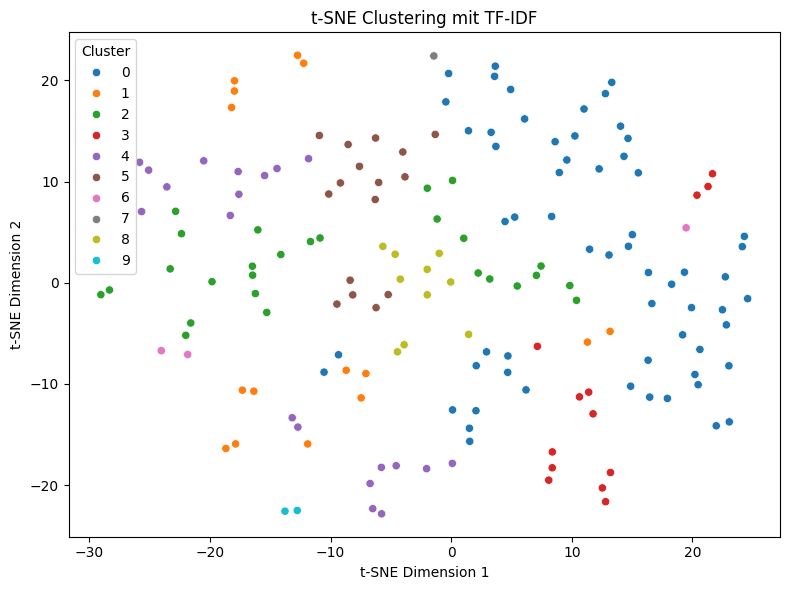

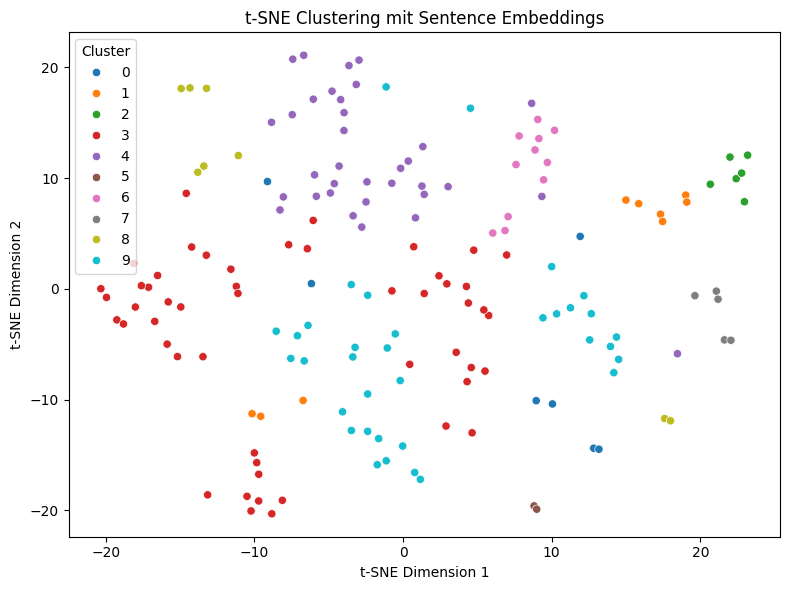

In [ ]:
from sklearn.manifold import TSNE
import seaborn as sns

def plot_tsne(vectors, labels, title):
    tsne = TSNE(n_components=2, perplexity=15, random_state=42)
    reduced = tsne.fit_transform(vectors)

    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=reduced[:, 0], y=reduced[:, 1], hue=labels, palette='tab10')
    plt.title(title)
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.legend(title="Cluster")
    plt.tight_layout()
    plt.show()

# t-SNE Plots für TF-IDF und Sentence Embeddings
plot_tsne(X_tfidf.toarray(), labels_tfidf, "t-SNE Clustering mit TF-IDF")
plot_tsne(embeddings, labels_emb, "t-SNE Clustering mit Sentence Embeddings")
